# 07 — Full-Text Résumé Screening: Job-Description Similarity

## Purpose
Score the LLM-generated full-text résumés by semantic similarity to a **job description**, and ask
whether that screening objective advantages or disadvantages older candidates — and *why*.

## Design
- **The headline is a job-description seniority sweep.** A single senior-flavored JD trivially favors
  senior résumés; that is not a finding. The finding is that **the age band that scores highest shifts
  upward as the job description becomes more senior**: score the *same* résumés against a junior, mid,
  senior, staff, and manager JD and the favored band moves from early/mid-career toward older groups.
  This is the text-embedding analogue of the reference-composition swap in notebook 06 and the incumbent
  swap in 08: *the comparison target sets the direction of the disparity*, not the résumés.
- **Two screening objectives, opposite gradients.** Job-description similarity (does the candidate match
  the role?) rewards the experience/leadership signals that correlate with age. The structured `callback`
  label, built from a biased, incumbent-style screening function, penalizes them. We show both side by side.
- **Analysis runs only on `faithfulness_ok == True`** résumés; the dropped rows are reported per group
  (tiny and age-flat, so nothing moves) and never enter a number.
- **Length is controlled, not just described.** Older résumés can run longer; we residualize similarity on
  *actual token length* and check the age gradient survives, rather than being a length artifact.
- **Embedder is one-line swappable** (`text-embedding-3-small` primary, `bge-m3` robustness pass), 8k-token
  context so no résumé is truncated, with the **embedding house-style caveat** stated up front.


## Imports & configuration

In [1]:
import sys
from pathlib import Path

# sole purpose: put the repo root on sys.path so `src` imports work
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.paths import PROJECT_ROOT, DATA_DIR, BASELINE_DIR, REPORTS_DIR, MODELS_DIR, EXPERIMENTS_DIR, EMBEDDINGS_DIR, TABLES_DIR, FIGURES_DIR, rel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib, json
from src.data_generation import dataset_fingerprint

ALLOW_EMBED_API = False   # cache-only default: a bare Run All can never re-embed or spend
FORCE_REEMBED  = False    # set True (with ALLOW_EMBED_API=True) to ignore caches deliberately

AGE_ORDER = ["<30", "30-39", "40-49", "50-59", "60+"]
# The text corpus is age-BALANCED (~2,500/band); the canonical synthetic population is not. Any POOLED
# ("overall") rate must be reweighted to these true proportions. Per-group rates need no reweighting.
TRUE_PROPORTIONS = {"<30": 0.25, "30-39": 0.30, "40-49": 0.25, "50-59": 0.15, "60+": 0.05}
SCREEN_RATE = 0.45
MODES = ["with_proxies", "without_direct_age_proxies", "minimal_proxy"]
FOCAL_MODE = "without_direct_age_proxies"   # the facially-neutral mode used for single-JD readouts

# ---- one-line swappable embedder -------------------------------------------------
# Same embedder is used for résumés AND job descriptions within a run; never mix across a comparison.
# Re-run with EMBEDDER="bge-m3" for the local robustness pass and compare the gradients qualitatively.
EMBEDDER = "openai"                              # "openai" (primary) | "bge-m3" (local robustness)
OPENAI_EMBED_MODEL = "text-embedding-3-small"    # 8,191-token context -> no résumé truncation
BGE_MODEL = "BAAI/bge-m3"                        # local, 8,192-token context
EMBED_BATCH = 256
print("embedder:", EMBEDDER)

embedder: openai


## 1. Load the three full-text résumé variants

In [2]:
frames, missing = [], []
for mode in MODES:
    p = EXPERIMENTS_DIR / f"synthetic_resumes_fulltext_{mode}.parquet"
    if not p.exists():
        missing.append(p); continue
    d = pd.read_parquet(p)
    d["generation_mode"] = mode
    frames.append(d)
if missing:
    raise FileNotFoundError("Missing generated files:\n" + "\n".join(f" - {m}" for m in missing))

fulltext = pd.concat(frames, ignore_index=True)
print("loaded:", fulltext.shape)
print("rows per mode:", fulltext.groupby("generation_mode", observed=True).size().to_dict())
print("prompt_version:", sorted(fulltext.get("prompt_version", pd.Series(dtype=str)).dropna().unique().tolist()))

fp_path = EXPERIMENTS_DIR / "fulltext_fingerprints.json"
fps = {mode: dataset_fingerprint(f) for mode, f in zip(MODES, frames)}
if fp_path.exists():
    prior = json.loads(fp_path.read_text())
    changed = sorted(m for m in MODES if prior.get(m) != fps[m])
    if changed:
        print(f"WARNING: fulltext corpus changed since blessed run: {changed}")
        print("         downstream tables/scored parquet will diverge from earlier results.")
    else:
        print("fulltext fingerprints match blessed corpus")
else:
    fp_path.write_text(json.dumps(fps, indent=2))
    print("blessed fulltext fingerprints ->", fp_path.name)

loaded: (37500, 81)
rows per mode: {'minimal_proxy': 12500, 'with_proxies': 12500, 'without_direct_age_proxies': 12500}
prompt_version: ['v6_varied_faithful_plaintext_nolabels']
fulltext fingerprints match blessed corpus


## 2. Faithfulness gate

We analyze only résumés that passed the generation-time faithfulness audit. The dropped rows are reported
per (mode, age) so it's on the record that the exclusion is small and roughly age-flat — i.e. it cannot
manufacture or hide a gradient.

In [3]:
fulltext["faithfulness_ok"] = fulltext["faithfulness_ok"].fillna(False).astype(bool)

dropped = (fulltext.assign(dropped=~fulltext["faithfulness_ok"])
           .groupby(["generation_mode", "age_group"], observed=True)["dropped"]
           .agg(dropped_rows="sum", dropped_rate="mean"))
dropped.to_csv(TABLES_DIR / "nlp07_faithfulness_dropped_by_mode_age.csv")
print(dropped.round(4).to_string())

analysis = fulltext[fulltext["faithfulness_ok"]].copy()
print(f"\nanalysis rows: {len(analysis)} of {len(fulltext)} ({len(analysis)/len(fulltext):.2%} kept)")

                                      dropped_rows  dropped_rate
generation_mode            age_group                            
minimal_proxy              <30                   5        0.0020
                           30-39                 0        0.0000
                           40-49                 2        0.0008
                           50-59                11        0.0044
                           60+                   6        0.0024
with_proxies               <30                   3        0.0012
                           30-39                 1        0.0004
                           40-49                 1        0.0004
                           50-59                 3        0.0012
                           60+                   3        0.0012
without_direct_age_proxies <30                   0        0.0000
                           30-39                 0        0.0000
                           40-49                 2        0.0008
                         

## 3. Independent text-level leakage audit

A second, independent check on the *text* (the generation audit ran at write time; this re-scans the
delivered corpus). It looks for placeholder artifacts, leaked field labels/bucket codes, explicit age
phrases, and evaluative age language. Bare ambiguous words ("young", "mature") are excluded here because
they collide with surnames; the name-stripped generation audit is authoritative for those.

*Methods note — generator regex gap.* The generation-time `AGE_LANGUAGE` retry-regex (which strips evaluative age language as résumés are generated) did not include the phrases *"decades of experience"*, *"long career"*, and *"late-career"*, so a small number of résumés carried them into the rendered text. The `evaluative_age_language` pattern in this independent audit does catch them: they are among the 74 rows the row-level `text_clean` gate drops downstream (skewed slightly toward the older bands), and the screening result is unchanged with or without that gate. This is a logged generator-regex gap caught at analysis time, not a regeneration trigger; the source fix is a one-line addition to the generator's `AGE_LANGUAGE` pattern.

In [4]:
AUDIT = {
    "bracket_placeholder":        r"\[[^\]]+\]",
    "unspecified_or_not_provided": r"\b(?:unspecified|not provided|details not provided)\b",
    "company_school_placeholder": r"\b(?:Company Name|School Name)\b",
    "numbered_certification":     r"\bCertification\s+[0-9]+\b",
    "field_label_artifact":       r"(?:University Tier|School Tier|Company Size|GPA Bucket|Tier:\s*\d|Size:\s*\d)",
    "highest_degree_none":        r"Highest Degree:\s*None",
    "protected_terms":            r"\b(?:true_age|age_group|protected class|fairness)\b",
    "explicit_age_phrase":        r"\b[0-9]{2}\s*(?:years old|year-old)\b",
    "evaluative_age_language":    r"\b(?:youthful|seasoned|veteran|elderly|recent graduate|fresh graduate|"
                                  r"mature professional|mature engineer|decades of experience|long career|late-career)\b",
}
rows = []
for mode, g in analysis.groupby("generation_mode", observed=True):
    t = g["resume_text"].fillna("")
    for label, pat in AUDIT.items():
        m = t.str.contains(pat, case=False, regex=True, na=False)
        rows.append({"generation_mode": mode, "pattern": label, "hits": int(m.sum()), "rate": float(m.mean())})
audit = pd.DataFrame(rows)
audit.to_csv(TABLES_DIR / "nlp07_text_leakage_audit.csv", index=False)
print(audit.pivot(index="pattern", columns="generation_mode", values="hits").fillna(0).astype(int).to_string())

# Row-level cleanliness gate: any résumé that trips the audit is excluded from the screening
# analysis. Computed here (after the embedding set is fixed) but applied at aggregation in §6, so
# the embedding cache — keyed on the full faithful corpus — stays valid and nothing re-embeds.
_HARD = "|".join(f"(?:{p})" for p in AUDIT.values())
analysis["text_clean"] = ~analysis["resume_text"].fillna("").str.contains(_HARD, case=False, regex=True, na=False)
_bymode = (~analysis["text_clean"]).groupby(analysis["generation_mode"], observed=True).sum()
print(); print(f"text-flagged rows dropped downstream: {int((~analysis['text_clean']).sum())} of {len(analysis)}",
      "->", _bymode.to_dict())

generation_mode              minimal_proxy  with_proxies  without_direct_age_proxies
pattern                                                                             
bracket_placeholder                      0             0                           0
company_school_placeholder               0             0                           0
evaluative_age_language                  0            11                          10
explicit_age_phrase                      0             0                           0
field_label_artifact                     2            17                          33
highest_degree_none                      0             0                           0
numbered_certification                   0             1                           0
protected_terms                          0             0                           0
unspecified_or_not_provided              0             0                           0

text-flagged rows dropped downstream: 74 of 37453 -> {'minimal_p

## 4. Embedder

`embed_texts` is the single swap point. Both backends L2-normalize, so cosine similarity is a dot product.
`embed_corpus` caches embeddings to disk keyed by (embedder, content hash): re-running the notebook does
not re-embed (or re-pay) unless the text changes.

*Caveat (embedding house style).* Unlike the mixed standardized/one-hot space in notebook 06, a sentence-
embedding cosine **is** a meaningful metric — but the numbers still reflect (a) the embedder's training, so
we run a second embedder (`bge-m3`) as a robustness pass, and (b) the JD's exact wording, which is why the
result below is a *sweep* over JDs rather than one JD. All résumés also share an LLM provenance; the
per-candidate STYLE variation in generation is what keeps that from inflating a shared-phrasing baseline.
We interpret the **ordering across age within a fixed (JD, embedder)**, not absolute values.

In [5]:
def _l2norm(M):
    M = np.asarray(M, dtype=np.float64)
    n = np.linalg.norm(M, axis=1, keepdims=True); n[n == 0] = 1.0
    return M / n

def _embed_openai(texts):
    import time, random
    from openai import OpenAI
    import openai as _oai
    client = OpenAI(max_retries=0)   # we own the backoff so a 429 never aborts mid-corpus
    retryable = tuple(c for c in (getattr(_oai, "RateLimitError", None),
                                  getattr(_oai, "APITimeoutError", None),
                                  getattr(_oai, "APIConnectionError", None),
                                  getattr(_oai, "InternalServerError", None)) if c)
    def _wait(exc, fallback):
        h = getattr(getattr(exc, "response", None), "headers", None) or {}
        ms, s = h.get("retry-after-ms"), h.get("retry-after")
        try:
            if ms is not None: return float(ms) / 1000.0
            if s is not None:  return float(s)
        except (TypeError, ValueError):
            pass
        return fallback
    out = []
    for i in range(0, len(texts), EMBED_BATCH):
        batch = [t if (isinstance(t, str) and t.strip()) else " " for t in texts[i:i + EMBED_BATCH]]
        for attempt in range(8):
            try:
                resp = client.embeddings.create(model=OPENAI_EMBED_MODEL, input=batch)
                out.extend(d.embedding for d in resp.data)
                break
            except retryable as e:
                if attempt == 7:
                    raise
                delay = _wait(e, 2.0 * (2 ** attempt)) + random.uniform(0.0, 0.5)
                print(f"\n  rate-limited; backing off {delay:.1f}s "
                      f"(batch {i // EMBED_BATCH + 1}, attempt {attempt + 1})")
                time.sleep(delay)
        print(f"  embedded {min(i + EMBED_BATCH, len(texts))}/{len(texts)}", end="\r")
    print()
    return _l2norm(out)

_bge = None
def _embed_bge(texts):
    global _bge
    from sentence_transformers import SentenceTransformer
    if _bge is None:
        _bge = SentenceTransformer(BGE_MODEL)
    safe = [t if (isinstance(t, str) and t.strip()) else " " for t in texts]
    emb = _bge.encode(safe, normalize_embeddings=True, batch_size=64, show_progress_bar=True)
    return np.asarray(emb, dtype=np.float64)

def embed_texts(texts):
    texts = list(texts)
    if EMBEDDER == "openai":  return _embed_openai(texts)
    if EMBEDDER == "bge-m3":  return _embed_bge(texts)
    raise ValueError(f"unknown EMBEDDER {EMBEDDER!r}")

def embed_corpus(texts, key):
    texts = list(texts)
    h = hashlib.sha256("\u0000".join(map(str, texts)).encode("utf-8")).hexdigest()[:12]
    model = OPENAI_EMBED_MODEL if EMBEDDER == "openai" else BGE_MODEL
    tag = f"{EMBEDDER}__{model}".replace("/", "_")
    cache = EMBEDDINGS_DIR / f"{tag}__{key}__{h}.npy"
    if cache.exists() and not FORCE_REEMBED:
        M = np.load(cache)
        if M.shape[0] == len(texts):
            print(f"  [cache] {cache.name}")
            return M
    if not ALLOW_EMBED_API:
        raise RuntimeError(
            f"Embedding cache miss: {cache.name} (ALLOW_EMBED_API=False).\n"
            "Restore the cache file, or set ALLOW_EMBED_API=True to (re)embed deliberately."
        )
    M = embed_texts(texts)
    np.save(cache, M)
    return M

def make_token_counter():
    try:
        import tiktoken
        enc = tiktoken.get_encoding("cl100k_base")
        return lambda s: len(enc.encode(s or ""))
    except Exception:
        return lambda s: int(len((s or "").split()) * 1.3)  # fallback length proxy
count_tokens = make_token_counter()
analysis["n_tokens"] = analysis["resume_text"].fillna("").map(count_tokens)
print("token length by age (median):",
      analysis.groupby("age_group", observed=True)["n_tokens"].median().reindex(AGE_ORDER).round(0).to_dict())

token length by age (median): {'<30': 221.0, '30-39': 296.0, '40-49': 343.0, '50-59': 343.0, '60+': 336.0}


## 5. Job-description ladder

Five postings spanning the seniority range, written to require progressively more experience, scope, and
leadership. The same résumés are scored against each; if "JD similarity favors older candidates" were a
property of the résumés, the favored band would not move across the ladder.

In [6]:
JOB_DESCRIPTIONS = {
"junior_swe": """Software Engineer I (New Grad / Early Career).
We are hiring an entry-level software engineer to join under the guidance of senior team members. You will
write and test features in Python or Java, learn our codebase and tools, fix bugs, and grow your
fundamentals in data structures, version control, and testing. We value curiosity, eagerness to learn, and
strong communication. No prior industry experience required; internships or academic projects welcome.""",
"mid_swe": """Software Engineer.
We are looking for a software engineer with a few years of experience to own features end to end. You will
design, build, and ship services in Python or Go, work with SQL databases and a cloud platform, write tests,
participate in code review, and collaborate with product partners. Solid fundamentals and the ability to work
independently on well-scoped problems are expected.""",
"senior_swe": """Senior Software Engineer.
We seek a senior engineer to design and operate reliable, scalable distributed systems. The role requires
deep experience with production reliability, Kubernetes, Linux, cloud platforms, infrastructure as code,
databases, and Python or Go, plus a track record of technical leadership on complex projects and mentoring
other engineers. You will set technical direction within a team and raise the bar on engineering quality.""",
"staff_swe": """Staff Software Engineer.
We are hiring a staff engineer to drive technical strategy across multiple teams. You will architect systems
spanning organizational boundaries, set engineering standards, lead the hardest distributed-systems and
reliability problems, and mentor senior engineers. Extensive experience designing large-scale production
systems and influencing technical direction at the org level is required.""",
"eng_manager": """Engineering Manager, Infrastructure.
We are looking for a hands-on engineering manager to lead a team building reliable, scalable cloud
infrastructure and developer platforms. The role requires people management, delivery ownership, experience
with distributed systems, production reliability, Kubernetes, Linux, cloud, and infrastructure as code, plus
cross-functional technical leadership, mentoring engineers, and improving operational maturity.""",
}
JD_ORDER = ["junior_swe", "mid_swe", "senior_swe", "staff_swe", "eng_manager"]
jd_emb = embed_corpus([JOB_DESCRIPTIONS[k] for k in JD_ORDER], key="jd_ladder")   # (5, d), normalized
print("JD embedding matrix:", jd_emb.shape)

  [cache] openai__text-embedding-3-small__jd_ladder__3225414e2cfd.npy
JD embedding matrix: (5, 1536)


## 6. Embed résumés and score against every JD

In [7]:
sim_blocks = []
for mode in MODES:
    sub = analysis[analysis.generation_mode == mode].reset_index(drop=True)
    M = embed_corpus(sub["resume_text"].fillna(" ").tolist(), key=f"resumes_{mode}")  # (n_m, d)
    S = M @ jd_emb.T   # (n_m, 5) cosine, both normalized
    block = sub[["candidate_id", "age_group", "generation_mode", "n_tokens", "text_clean"]].copy()
    for j, k in enumerate(JD_ORDER):
        block[f"sim__{k}"] = S[:, j]
    sim_blocks.append(block)
sim = pd.concat(sim_blocks, ignore_index=True)
_n = len(sim); sim = sim[sim["text_clean"]].reset_index(drop=True)
print(f"scored frame: {sim.shape}  (dropped {_n - len(sim)} text-flagged rows; embeddings cached on full faithful set)")

  [cache] openai__text-embedding-3-small__resumes_with_proxies__1767c7e6e9af.npy
  [cache] openai__text-embedding-3-small__resumes_without_direct_age_proxies__19e723a978ee.npy
  [cache] openai__text-embedding-3-small__resumes_minimal_proxy__f1132f362fab.npy
scored frame: (37379, 10)  (dropped 74 text-flagged rows; embeddings cached on full faithful set)


## 7. Headline — the JD-seniority sweep

Mean similarity by age, for each rung of the JD ladder (focal mode). the argmax table shows the favored band shifting from early/mid-career toward older groups as the JD gets more senior. That shift, not the level for any one JD, is the result: the direction of the disparity is a property of the target, not the candidates.



In [8]:
def mean_ci(x):
    x = np.asarray(x, dtype=float); n = len(x)
    m = float(x.mean()) if n else np.nan
    h = 1.96 * x.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    return m, m - h, m + h

focal = sim[sim.generation_mode == FOCAL_MODE]
rows = []
for k in JD_ORDER:
    for ag in AGE_ORDER:
        m, lo, hi = mean_ci(focal[focal.age_group == ag][f"sim__{k}"])
        rows.append({"jd": k, "age_group": ag, "n": int((focal.age_group == ag).sum()),
                     "mean_sim": m, "lo": lo, "hi": hi})
sweep = pd.DataFrame(rows)
sweep.to_csv(TABLES_DIR / "nlp07_similarity_by_jd_and_age.csv", index=False)

argmax = (sweep.loc[sweep.groupby("jd")["mean_sim"].idxmax(), ["jd", "age_group", "mean_sim"]]
          .set_index("jd").reindex(JD_ORDER))
print("Favored (highest-similarity) age band by JD seniority:")
print(argmax.round(4).to_string())

Favored (highest-similarity) age band by JD seniority:
            age_group  mean_sim
jd                             
junior_swe      30-39    0.4196
mid_swe         30-39    0.4716
senior_swe      40-49    0.4805
staff_swe       40-49    0.4488
eng_manager       60+    0.4466


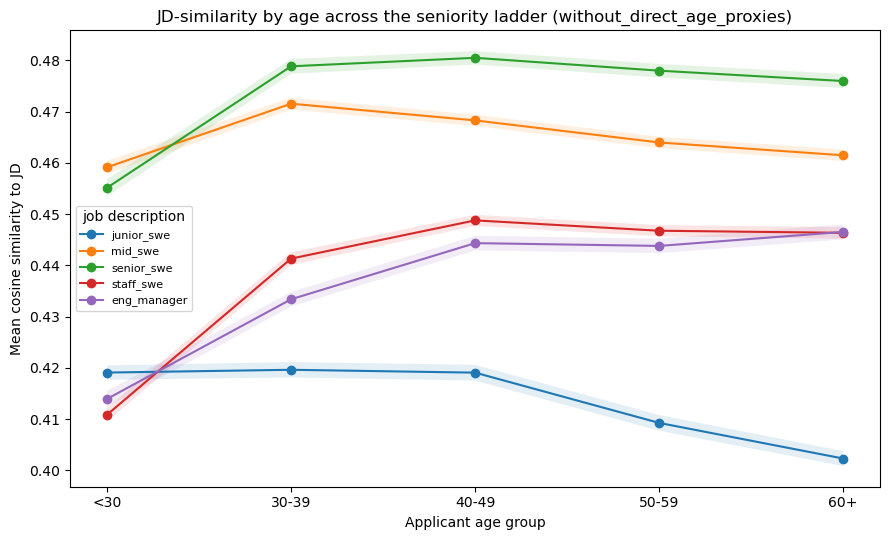

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
xs = np.arange(len(AGE_ORDER))
for k in JD_ORDER:
    d = sweep[sweep.jd == k].set_index("age_group").reindex(AGE_ORDER)
    ax.plot(xs, d["mean_sim"], marker="o", label=k)
    ax.fill_between(xs, d["lo"], d["hi"], alpha=0.12)
ax.set_xticks(xs); ax.set_xticklabels(AGE_ORDER)
ax.set_xlabel("Applicant age group"); ax.set_ylabel("Mean cosine similarity to JD")
ax.set_title(f"JD-similarity by age across the seniority ladder ({FOCAL_MODE})")
ax.legend(title="job description", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "nlp07_jd_seniority_sweep.png", dpi=150)
plt.show()

## 8. Length control

Older résumés may simply be longer (more experience → more text). We residualize the manager-JD similarity
on a quadratic in *actual token length* and compare the raw age gradient to the length-adjusted one. If the
ordering survives, the gradient is not merely a length artifact.

In [10]:
foc = focal.copy()
foc["sim"] = foc["sim__eng_manager"]
x = foc["n_tokens"].to_numpy(float); y = foc["sim"].to_numpy(float)
coef = np.polyfit(x, y, 2)
foc["sim_resid"] = y - np.polyval(coef, x)

ctl = pd.DataFrame({
    "mean_tokens":        foc.groupby("age_group", observed=True)["n_tokens"].mean().reindex(AGE_ORDER),
    "raw_mean_sim":       foc.groupby("age_group", observed=True)["sim"].mean().reindex(AGE_ORDER),
    "length_adj_mean_sim": foc.groupby("age_group", observed=True)["sim_resid"].mean().reindex(AGE_ORDER),
})
ctl.to_csv(TABLES_DIR / "nlp07_length_control_eng_manager.csv")
print(f"corr(similarity, tokens) = {np.corrcoef(x, y)[0,1]:.3f}")
print(ctl.round(4).to_string())

corr(similarity, tokens) = 0.201
           mean_tokens  raw_mean_sim  length_adj_mean_sim
age_group                                                
<30           253.3461        0.4140              -0.0150
30-39         352.9723        0.4334              -0.0026
40-49         418.3706        0.4444               0.0050
50-59         413.1221        0.4438               0.0047
60+           400.5772        0.4466               0.0081


The manager-JD gradient is partly correlated with résumé length, but it does not disappear after residualizing similarity on a quadratic function of token count. The remaining ordering suggests that the screen is responding to seniority/leadership language, not merely longer documents.

## 9. Screen-in rate by age (manager JD)

Top-`SCREEN_RATE` of similarity scores are "screened in", with Wilson 95% intervals per band. The pooled
rate is reweighted to the true population proportions, since the corpus is age-balanced by construction.

In [11]:
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k / n; d = 1 + z * z / n
    c = p + z * z / (2 * n); h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return p, (c - h) / d, (c + h) / d

thr = foc["sim"].quantile(1 - SCREEN_RATE)
foc["screened_in"] = foc["sim"] >= thr
rows = []
for ag in AGE_ORDER:
    s = foc[foc.age_group == ag]["screened_in"]
    p, lo, hi = wilson(int(s.sum()), int(len(s)))
    rows.append({"age_group": ag, "n": int(len(s)), "screen_rate": p, "lo": lo, "hi": hi})
screen = pd.DataFrame(rows).set_index("age_group")
screen.to_csv(TABLES_DIR / "nlp07_screen_rates_eng_manager.csv")
pooled = sum(TRUE_PROPORTIONS[ag] * screen.loc[ag, "screen_rate"] for ag in AGE_ORDER)
print(screen.round(3).to_string())
print(f"\nsynthetic-population-reweighted overall screen-in rate: {pooled:.3f}  (within-corpus target {SCREEN_RATE})")

              n  screen_rate     lo     hi
age_group                                 
<30        2499        0.246  0.230  0.264
30-39      2493        0.408  0.388  0.427
40-49      2493        0.528  0.509  0.548
50-59      2481        0.520  0.500  0.540
60+        2479        0.549  0.529  0.569

synthetic-population-reweighted overall screen-in rate: 0.421  (within-corpus target 0.45)


## 10. Two screening objectives, opposite gradients

The structured `callback` label came from a biased, incumbent-style screening function (notebooks 01–05);
job-description similarity asks a different question. Put the two age gradients next to each other.

In [12]:
if "callback" in analysis.columns:
    cb = analysis[(analysis.generation_mode == FOCAL_MODE) & analysis["text_clean"]].copy()
    cb["cb"] = cb["callback"].astype(str).str.lower().map({"true": 1.0, "false": 0.0})
    cb["cb"] = cb["cb"].fillna(pd.to_numeric(cb["callback"], errors="coerce"))
    cmp = pd.DataFrame({
        "jd_similarity_screen_rate": screen["screen_rate"],
        "structured_callback_rate":  cb.groupby("age_group", observed=True)["cb"].mean().reindex(AGE_ORDER),
    })
    cmp.to_csv(TABLES_DIR / "nlp07_jdsim_vs_callback.csv")
    print(cmp.round(3).to_string())
else:
    print("no callback column present; skipping contrast")

           jd_similarity_screen_rate  structured_callback_rate
age_group                                                     
<30                            0.246                     0.595
30-39                          0.408                     0.649
40-49                          0.528                     0.466
50-59                          0.520                     0.192
60+                            0.549                     0.054


## 11. Within-candidate mode deltas

Each candidate has three rendered versions, so we can hold the structured candidate constant and isolate
the effect of removing proxies. In this embedding setup, removing direct date proxies and even rendering
the broader minimal-proxy version moves manager-JD similarity only slightly. That suggests the seniority
signal is distributed through role, scope, skills, and experience language rather than isolated in explicit
date fields.

In [13]:
wide = sim.pivot_table(index=["candidate_id", "age_group"], columns="generation_mode",
                       values="sim__eng_manager", aggfunc="first", observed=False).reset_index()
if set(MODES).issubset(wide.columns):
    wide["d_with_minus_without"]   = wide["with_proxies"] - wide["without_direct_age_proxies"]
    wide["d_without_minus_minimal"] = wide["without_direct_age_proxies"] - wide["minimal_proxy"]
    dsum = (wide.groupby("age_group", observed=True)[["d_with_minus_without", "d_without_minus_minimal"]]
            .mean().reindex(AGE_ORDER))
    dsum.to_csv(TABLES_DIR / "nlp07_mode_deltas_eng_manager.csv")
    print(dsum.round(4).to_string())
else:
    print("not all modes present; skipping within-candidate deltas")

generation_mode  d_with_minus_without  d_without_minus_minimal
age_group                                                     
<30                           -0.0082                   0.0041
30-39                         -0.0045                   0.0016
40-49                         -0.0042                  -0.0007
50-59                         -0.0029                   0.0004
60+                           -0.0031                   0.0011


## 12. Save the scored dataset

In [14]:
scored_path = EXPERIMENTS_DIR / f"synthetic_resumes_fulltext_scored_{EMBEDDER.replace('/', '_')}.parquet"
sim.to_parquet(scored_path, index=False)
meta = {
    "embedder": EMBEDDER,
    "model": OPENAI_EMBED_MODEL if EMBEDDER == "openai" else BGE_MODEL,
    "prompt_version": sorted(fulltext["prompt_version"].dropna().unique().tolist()),
    "input_fingerprints": fps,
    "rows": int(len(sim)),
}
scored_path.with_suffix(".meta.json").write_text(json.dumps(meta, indent=2))
print("wrote", rel(scored_path))
print("tables ->", rel(TABLES_DIR))
print("figures ->", rel(FIGURES_DIR))

wrote data/experiments/synthetic_resumes_fulltext_scored_openai.parquet
tables -> reports/tables
figures -> reports/figures


## 13. Key findings

1. **The favored age band shifts with the job description's seniority.** Scored against junior and mid-level postings, the peak is 30–39; against senior, staff, and manager postings, the peak moves into older groups. The age gradient is a property of the *comparison target*, not an inherent property of the résumés: the text-embedding analogue of the reference-composition swap in 06 and the incumbent swap in 08.  
2. **Job-description similarity and the biased `callback` label point in opposite directions.** Job-fit
   similarity rewards the experience/leadership signals that correlate with age; the incumbent-style callback
   penalizes them. Which one a real system optimizes for determines the fairness outcome.
3. **The senior-JD gradient is not just a length effect** — it largely survives residualizing similarity on
   actual token length.
4. **Removing direct date proxies barely moves similarity.** In this embedding setup, both direct-date removal and broader minimal-proxy rendering move manager-JD similarity only slightly. The age-correlated signal appears distributed across role, scope, skills, and experience language rather than isolated in graduation year.
5. **Caveats.** Cosine over a sentence-embedding space is meaningful but embedder- and JD-wording-dependent
   (hence the `bge-m3` robustness pass and the JD sweep); résumés share an LLM provenance (mitigated by
   per-candidate style variation); magnitudes are illustrative of a synthetic corpus, and only the
   cross-age ordering within a fixed (JD, embedder) is interpreted.
